<a href="https://colab.research.google.com/github/100472373/P1_AprendizajeAutomatico/blob/main/P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Alvaro Rodríguez Vázquez 100472346\
Adrián Calderón Canales  100472373\
Grupo 84\
Grupo clase 12\
https://github.com/100472373/P2_AprendizajeAutomatico.git

# **1. Introducción**

## Importación de librerías

In [ ]:
# Análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import os
import random

# Gráficos
sns.set(style="whitegrid")
%matplotlib inline


## Importación dataset

In [ ]:
# Cargamos el dataset
df = pd.read_csv("semillas.csv")

# Mostramos las primeras filas
df.head()


,area,perimetro,compacidad,longitud,anchura,asimetria,surco,clase
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


El conjunto de datos contiene medidas numéricas de distintas semillas de cereales. La última columna representa la clase de la semilla, que **que no usamos en la fase de clustering**, pero sí utilizamos para posteriores análisis.


## Anális y Separación de variables

In [ ]:
# Información del dataframe
df.info()

# Comprobamos valores nulos
print("\n¿Valores nulos?:", df.isnull().values.any())

# Separamos variables predictivas y clase
X = df.drop(columns=['clase'])
y = df['clase']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        210 non-null    float64
 1   perimetro   210 non-null    float64
 2   compacidad  210 non-null    float64
 3   longitud    210 non-null    float64
 4   anchura     210 non-null    float64
 5   asimetria   210 non-null    float64
 6   surco       210 non-null    float64
 7   clase       210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB

¿Valores nulos?: False


Comprobamos que todos los atributos son numéricos y que no existen valores nulos en el dataset. Separamos los datos en dos partes:

- `X`: contiene las variables predictivas, que serán usadas para el preprocesado y clustering.
- `y`: contiene la clase de cada semilla, que solo se usará en el análisis del rendimiento de los clusters.


## Fijación semilla

In [ ]:
# Semilla base (NIA Adrián Calderón)
NIA = 100472373

# Fijamos semillas
np.random.seed(NIA)
random.seed(NIA)


Fijamos una semilla utilizando el NIA de un miembro del grupo (Adrián Calderón).

# **2. Visualización con PCA y selección del mejor scaler**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

def ejec_scaler(X, scaler, n_components=2):
    pipeline = Pipeline([
        ('scaler', scaler),
        ('pca', PCA(n_components=n_components, random_state=NIA))
    ])
    X_pca = pipeline.fit_transform(X)
    return X_pca, pipeline


Creamos una función que aplica un escalador seguido de un análisis PCA con 2 componentes. Utilizamos un pipeline de Scikit-Learn para asegurar que la transformación sea ordenada. El `random_state` del PCA se fija usando el NIA para mantener la reproducibilidad.


## Aplicar los tres escaladores y visualizar

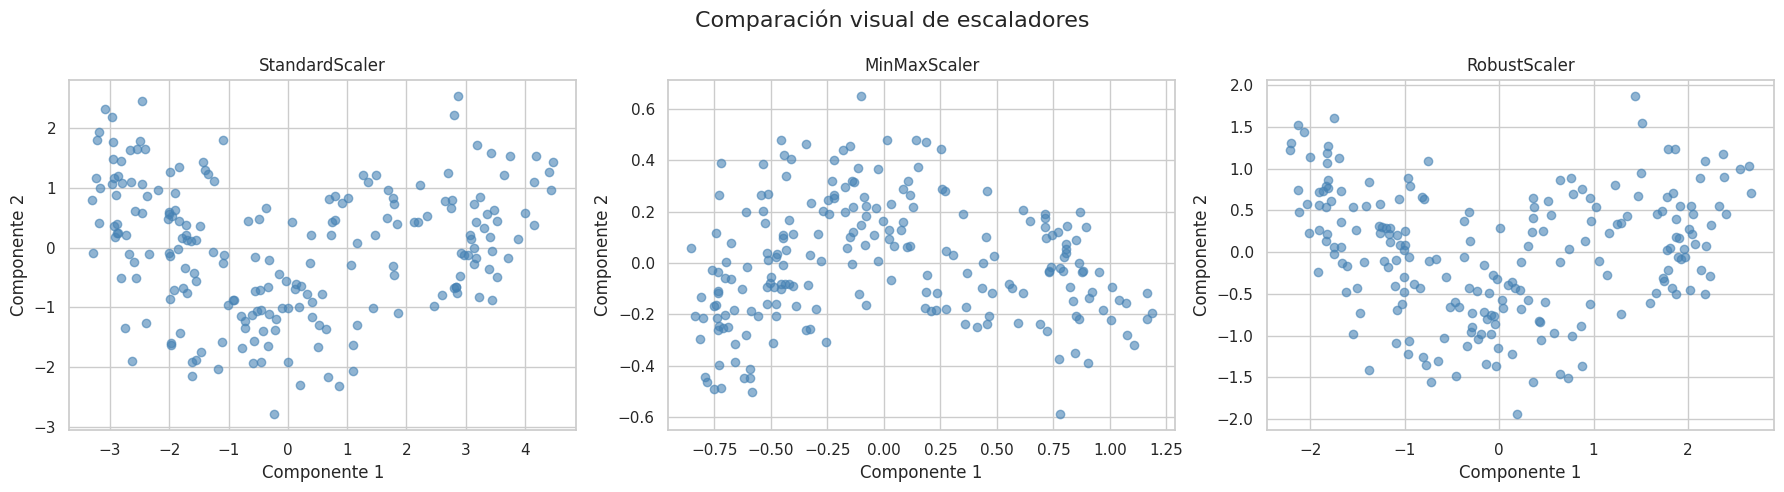

In [ ]:
# Escaladores a probar
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# Visualización
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, (nombre, scaler) in enumerate(scalers.items()):
    X_pca, _ = ejec_scaler(X, scaler)

    axs[i].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color='steelblue')
    axs[i].set_title(f'{nombre}')
    axs[i].set_xlabel('Componente 1')
    axs[i].set_ylabel('Componente 2')
    axs[i].grid(True)

plt.suptitle("Comparación visual de escaladores", fontsize=16)
plt.tight_layout()
plt.show()


Aplicamos tres métodos de escalado (Standard, MinMax y Robust) seguidos de PCA para reducir los datos a 2 dimensiones. Representamos los datos sin usar etiquetas de clase (unsupervised) para evaluar si se observan agrupaciones o separaciones evidentes entre puntos.

La comparación visual nos ayudará a seleccionar el preprocesamiento más informativo antes de aplicar técnicas de clustering.


## Selección del mejor scaler


En la figura anterior se presentan las proyecciones bidimensionales del conjunto de datos tras aplicar un análisis de componentes principales (PCA) con 2 componentes, precedido por tres métodos distintos de escalado:

- `StandardScaler`: escala los atributos centrando la media en 0 y variancia unitaria.
- `MinMaxScaler`: reescala los atributos al rango [0, 1].
- `RobustScaler`: utiliza estadísticas robustas (mediana y rango intercuartílico) para escalar, menos sensibles a valores atípicos.

Análisis visual

- **StandardScaler**:
  - La distribución de los puntos muestra una estructura curva evidente, con cierta dispersión.
  - Se observa una posible segmentación de grupos a lo largo de la primera componente principal.
  - No hay agrupamientos perfectamente definidos, pero sí se aprecia cierta separación útil para clustering.
  
- **MinMaxScaler**:
  - Los puntos están comprimidos en un espacio muy reducido (rango forzado [0, 1]).
  - La visualización muestra una superposición mayor entre posibles grupos.

- **RobustScaler**:
  - Muestra una distribución más expandida que MinMax, pero menos estructurada que StandardScaler.
  - Aunque es útil frente a outliers, no parece resaltar agrupaciones naturales ni separaciones claras en este caso.

Conclusión

A partir de la evaluación visual, el escalador que mejor respeta la estructura potencial de los datos para aplicar técnicas de clustering es:

> **`StandardScaler`**

Este método mantiene una separación más clara a lo largo de los ejes principales y parece ofrecer la mejor base para detectar agrupamientos reales mediante algoritmos no supervisados.

# **3. Clustering no supervisado**

## K-MEANS Clustering

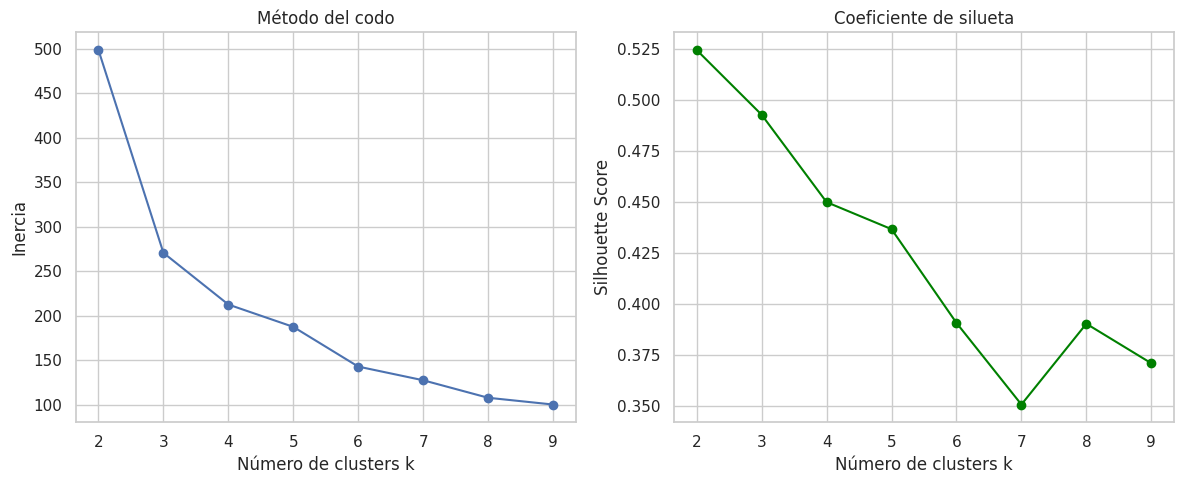

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Datos preprocesados con StandardScaler + PCA
X_pca_std, pipeline_std = ejec_scaler(X, StandardScaler())


siluetas = []
inercia = []
rango_K = range(2, 10)

for k in rango_K:
    kmeans = KMeans(n_clusters=k, random_state=NIA)
    kmeans.fit(X_pca_std)
    inercia.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X_pca_std, kmeans.labels_))

# Gráfica de codo y silueta
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(rango_K, inercia, marker='o')
ax[0].set_title("Método del codo")
ax[0].set_xlabel("Número de clusters k")
ax[0].set_ylabel("Inercia")

ax[1].plot(rango_K, siluetas, marker='o', color='green')
ax[1].set_title("Coeficiente de silueta")
ax[1].set_xlabel("Número de clusters k")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


Para determinar el valor óptimo de `k` en el algoritmo K-Means, hemos considerado dos métricas complementarias:

- **Método del codo**: muestra un descenso brusco en la inercia hasta `k = 3`, donde se aprecia un punto de inflexión. Esto sugiere que tres clusters explican la mayor parte de la estructura sin añadir complejidad innecesaria.
- **Coeficiente de silueta**: alcanza su valor máximo en `k = 2`, pero `k = 3` mantiene un valor elevado, indicando aún una buena separación y cohesión de los clusters.

Aunque el valor máximo de silueta se da en `k = 2`, optamos por `k = 3` ya que:
- Representa una estructura más detallada,
- Tiene un respaldo claro en el método del codo,
- Es coherente con el número real de clases.

Por tanto, **elegimos `k = 3` como valor óptimo para aplicar K-Means.**



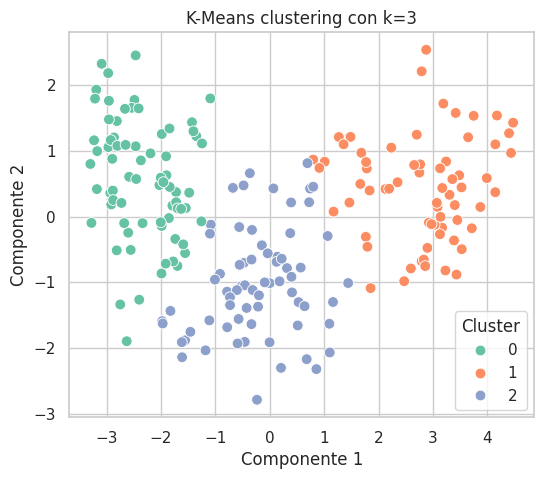

In [ ]:
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=NIA)
etiq_kmeans = kmeans.fit_predict(X_pca_std)

# Visualización
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca_std[:, 0], y=X_pca_std[:, 1], hue=etiq_kmeans, palette="Set2", s=60)
plt.title(f"K-Means clustering con k={k_optimo}")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


### K-Means clustering final

Usamos el valor óptimo de `k` estimado previamente para aplicar K-Means. El gráfico muestra la agrupación resultante en el espacio PCA (2D). Cada color representa un cluster diferente detectado por el algoritmo.


## Clustering Jerárquico

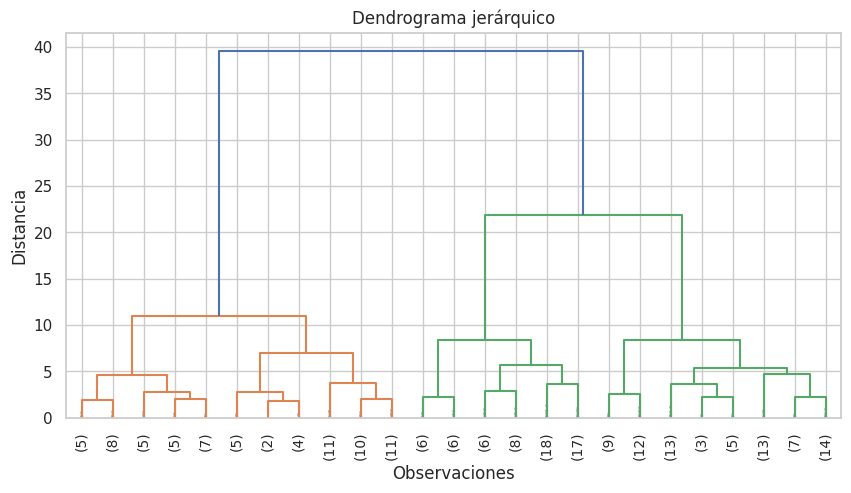

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

X = linkage(X_pca_std, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(X, truncate_mode='lastp', p=25, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title("Dendrograma jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.grid(True)
plt.show()


Observando el dendrograma generado con el método `ward`, detectamos un salto importante en la distancia alrededor de 40 unidades, correspondiente a la fusión final de dos grandes ramas. Este cambio brusco indica que fusionar más allá de este punto implica juntar grupos muy disímiles.

Justo antes de esa fusión, el dendrograma muestra **tres ramas principales**, lo que nos indica que cortar en ese punto nos da **3 clusters bien diferenciados**.

Por tanto, **elegimos `n_clusters = 3` para aplicar el algoritmo `AgglomerativeClustering`**.


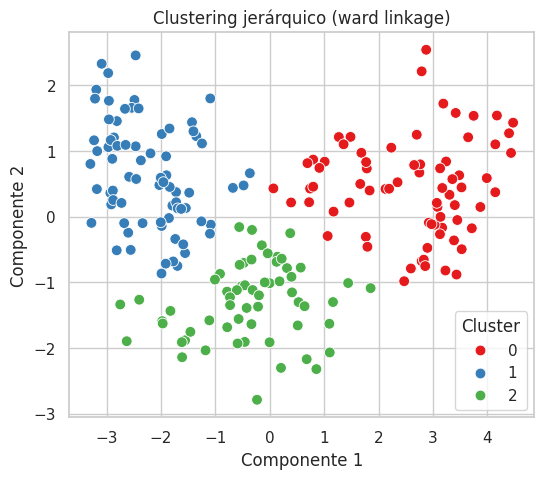

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Decidimos usar 3 clusters
jerarq = AgglomerativeClustering(n_clusters=3, linkage='ward')
etiq_jera = jerarq.fit_predict(X_pca_std)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca_std[:, 0], y=X_pca_std[:, 1], hue=etiq_jera, palette="Set1", s=60)
plt.title("Clustering jerárquico (ward linkage)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


### Clustering jerárquico final

Aplicamos `AgglomerativeClustering` con el número de clusters elegido a partir del dendrograma. El resultado muestra cómo se agrupan las observaciones en el espacio reducido por PCA.


### Comparación de métodos de linkage

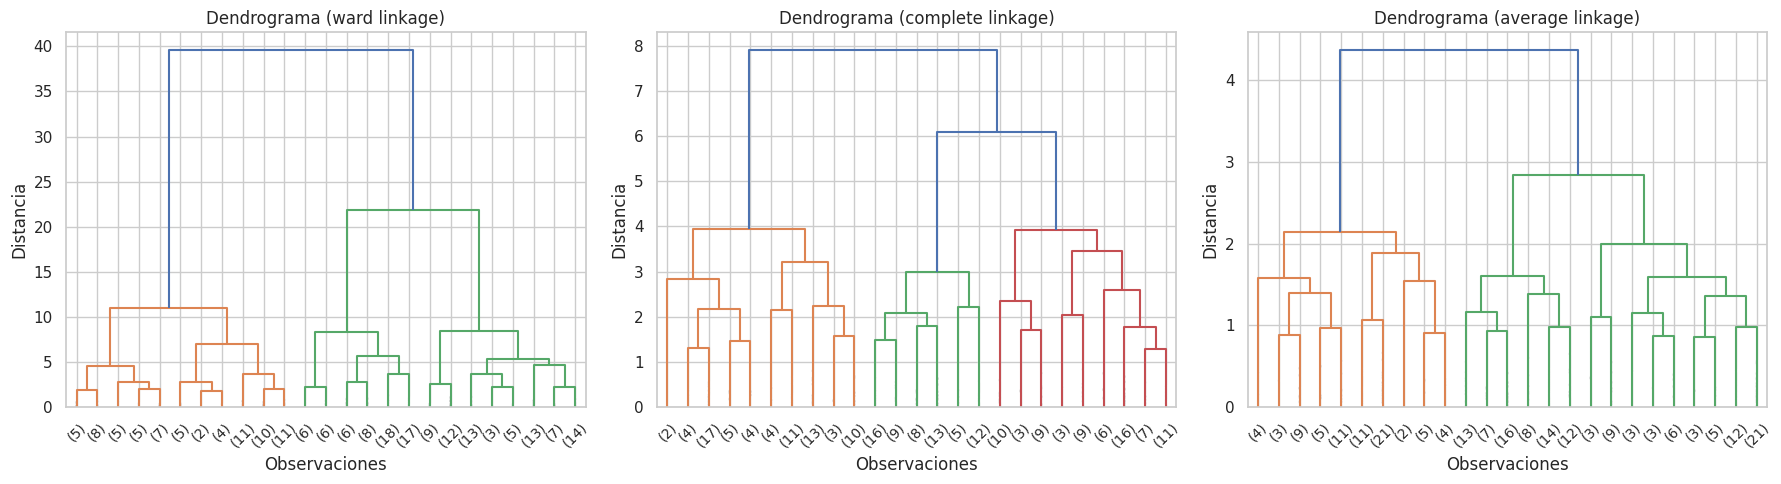

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

metodos_linkage = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, metodos_linkage):
    Z = linkage(X_pca_std, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=25, show_contracted=True)
    ax.set_title(f"Dendrograma ({method} linkage)")
    ax.set_xlabel("Observaciones")
    ax.set_ylabel("Distancia")

plt.tight_layout()
plt.show()


Se han comparado tres métodos de enlace jerárquico (`ward`, `complete`, `average`) mediante dendrogramas truncados. A partir de los gráficos, observamos:

- `ward` produce **una estructura más clara y jerárquica**, con un salto significativo en la distancia (≈ 40) que sugiere 3 agrupaciones naturales.
- `complete` y `average` generan dendrogramas más compactos, pero con **menos separación evidente entre grupos**, lo que dificulta la elección del número óptimo de clusters. No muestran una jerarquía tan marcada.

Por tanto, seleccionamos el método **`ward`** con **`n_clusters = 3`** para aplicar el algoritmo `AgglomerativeClustering`, ya que es el que mejor refleja la estructura interna del dataset.


## Clustering con DBSCAN

### Visualizar la gráfica k-dist para determinar eps

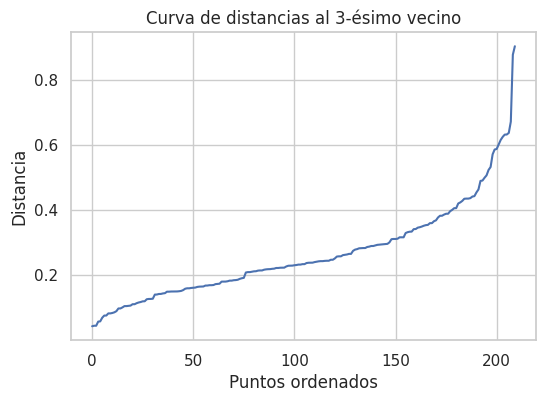

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Probamos con el valor de  minPts recomendado
minPts = 3

# Calculamos distancias del minPts-ésimo vecino
vec_cerc = NearestNeighbors(n_neighbors=minPts)
vec_cerc.fit(X_pca_std)
dist, _ = vec_cerc.kneighbors(X_pca_std)

# Extraemos la distancia al minPts-ésimo vecino
k_distances = np.sort(dist[:, -1])

# Grafica
plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.title(f"Curva de distancias al {minPts}-ésimo vecino")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia")
plt.grid(True)
plt.show()


La curva de distancias al vecino número `minPts` permite identificar el valor óptimo de `eps` como el **punto de inflexión**, donde la distancia comienza a crecer rápidamente.

En nuestro caso, observamos un cambio brusco a partir de **`eps = 0.35`**, que consideramos como umbral para distinguir regiones densas (clusters) de regiones ruidosas.

Por tanto, **seleccionamos `eps = 0.35` como valor final**.


### Exploración de parámetros

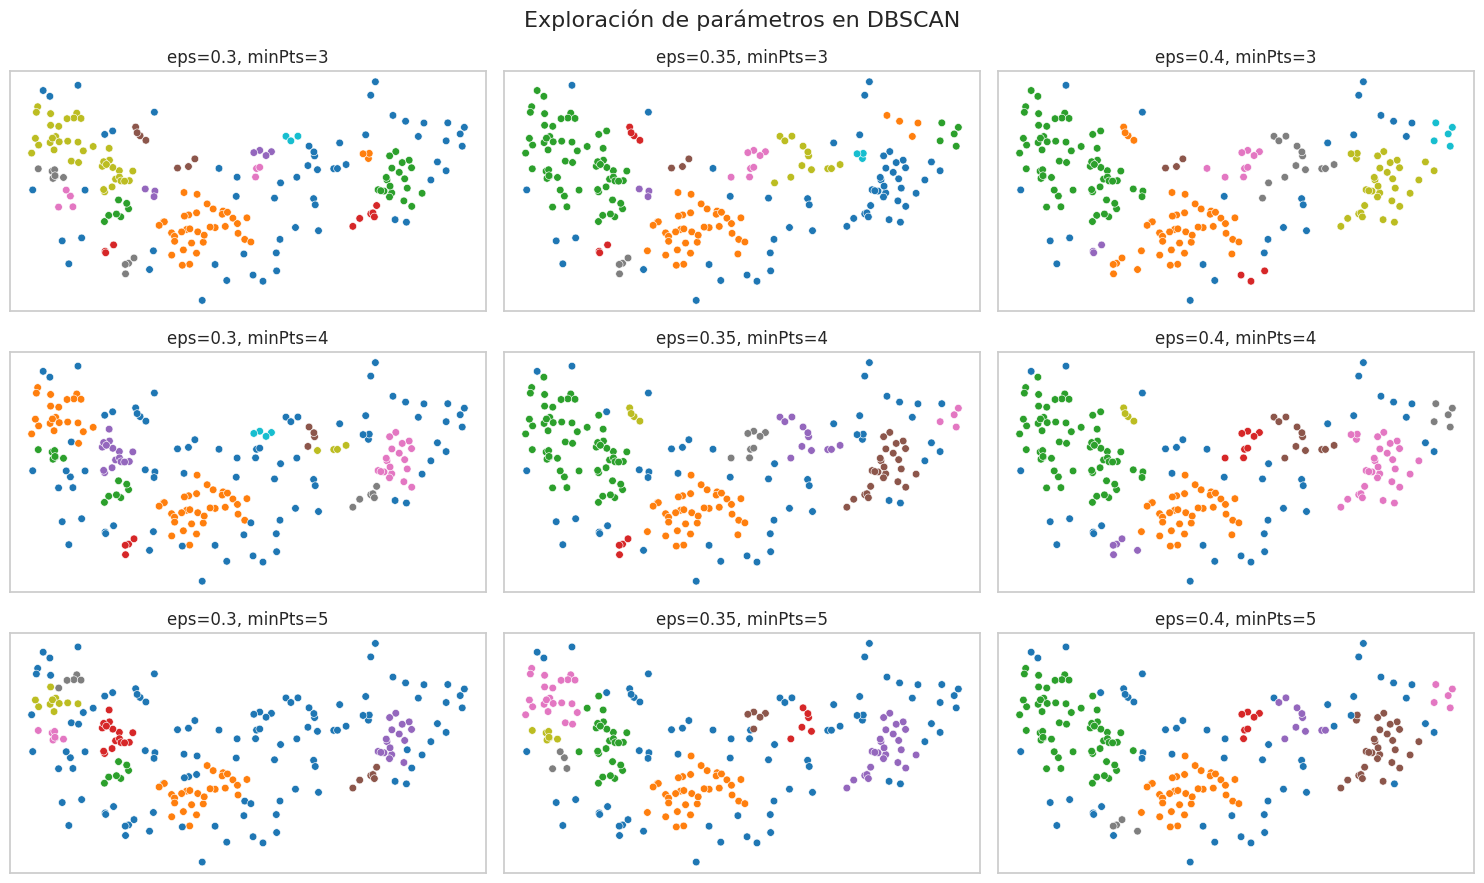

In [ ]:
from sklearn.cluster import DBSCAN
import seaborn as sns

minPts_vals = [3, 4, 5]
eps_vals = [0.3, 0.35, 0.4]

fig, axes = plt.subplots(len(minPts_vals), len(eps_vals), figsize=(15, 9), sharex=True, sharey=True)

for i, minpts in enumerate(minPts_vals):
    for j, eps in enumerate(eps_vals):
        db = DBSCAN(eps=eps, min_samples=minpts)
        labels = db.fit_predict(X_pca_std)

        ax = axes[i, j]
        sns.scatterplot(x=X_pca_std[:, 0], y=X_pca_std[:, 1],
                        hue=labels, palette='tab10', ax=ax, s=30, legend=None)
        ax.set_title(f"eps={eps}, minPts={minpts}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Exploración de parámetros en DBSCAN", fontsize=16)
plt.tight_layout()
plt.show()


Hemos realizado un análisis de combinaciones de los parámetros `eps` y `min_samples` en DBSCAN. A partir del análisis visual de los resultados, seleccionamos:

- **`eps = 0.35`**
- **`min_samples = 4`**

Esta combinación produce una segmentación clara y equilibrada:
- Identifica tres clusters principales bien separados.
- No deja un exceso de puntos como ruido.
- Evita tanto la sobrefragmentación como la fusión artificial de zonas dispersas.

Las configuraciones con `eps = 0.3` generan demasiados grupos pequeños, y con `eps = 0.4` tienden a fusionar regiones separadas, disminuyendo la nitidez del resultado.

Por tanto, consideramos `eps = 0.35` y `min_samples = 4` como la mejor configuración para DBSCAN en este conjunto de datos.


### DBSCAN final y visualización

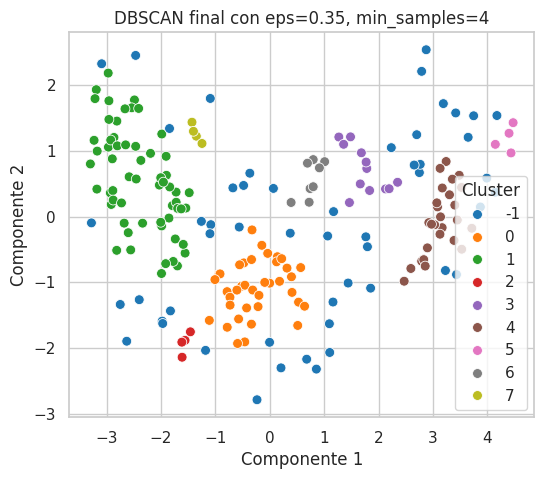

In [ ]:
# Modelo DBSCAN final
dbscan_final = DBSCAN(eps=0.35, min_samples=4)
dbscan_etiq = dbscan_final.fit_predict(X_pca_std)

# Visualización
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca_std[:, 0], y=X_pca_std[:, 1],
                hue=dbscan_etiq, palette='tab10', s=50)
plt.title("DBSCAN final con eps=0.35, min_samples=4")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


DBSCAN ha sido aplicado con los parámetros:

- `eps = 0.35`
- `min_samples = 4`

Esta configuración produce una segmentación clara del espacio de datos. A diferencia de K-Means y AgglomerativeClustering, DBSCAN es capaz de:

- Detectar **puntos atípicos o ruido** (`label = -1`)
- Agrupar observaciones sin establecer un número de clusters fijo
- Conservar **estructura local** incluso en clusters de diferente tamaño


# **4. Análisis**

## Comparativa de los clusters

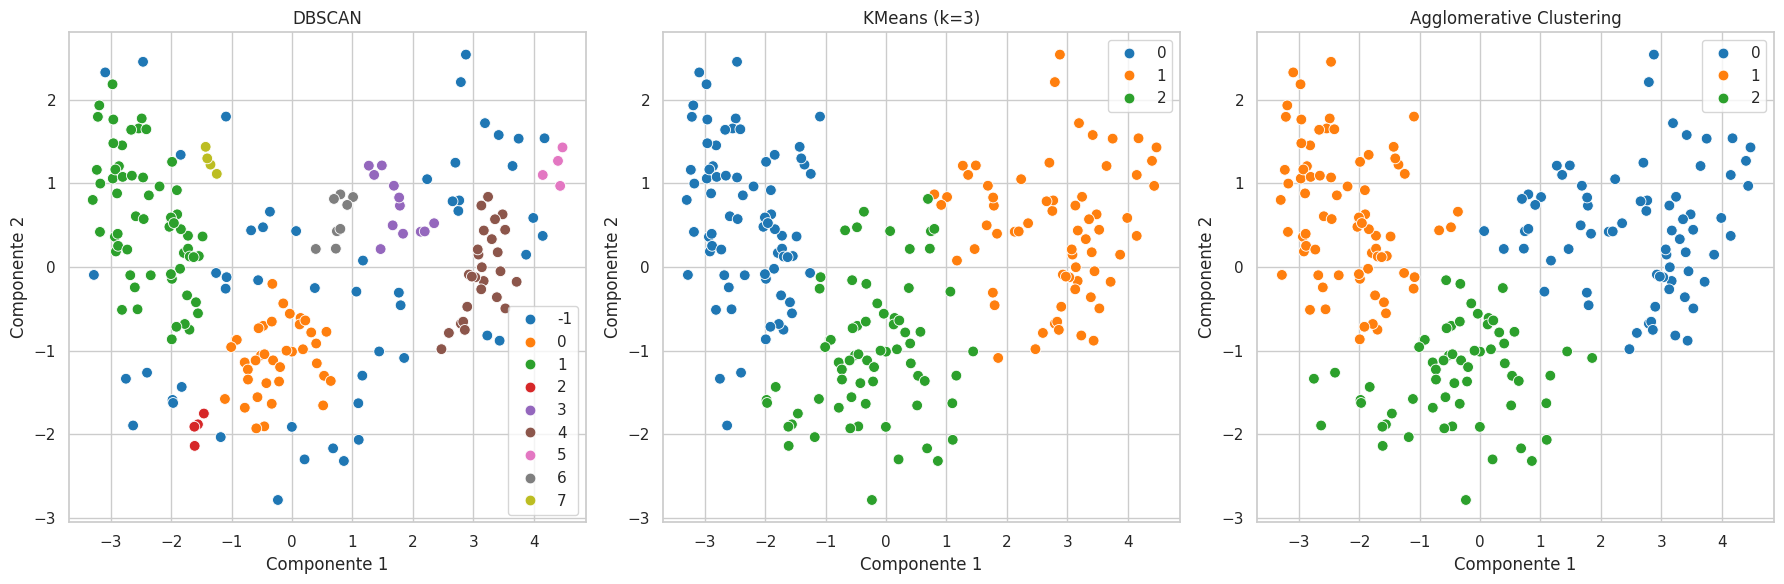

In [ ]:
# KMeans con k=3
kmeans = KMeans(n_clusters=3, random_state=NIA)
etiq_kmeans = kmeans.fit_predict(X_pca_std)

# AgglomerativeClustering con n_clusters=3
agg = AgglomerativeClustering(n_clusters=3)
etiq_agg = agg.fit_predict(X_pca_std)

# Visulizamos los resultados de los tres métodos
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# DBSCAN
sns.scatterplot(x=X_pca_std[:, 0], y=X_pca_std[:, 1], hue=dbscan_etiq, palette='tab10', ax=axs[0], s=60)
axs[0].set_title("DBSCAN")
axs[0].set_xlabel("Componente 1")
axs[0].set_ylabel("Componente 2")

# KMeans
sns.scatterplot(x=X_pca_std[:, 0], y=X_pca_std[:, 1], hue=etiq_kmeans, palette='tab10', ax=axs[1], s=60)
axs[1].set_title("KMeans (k=3)")
axs[1].set_xlabel("Componente 1")
axs[1].set_ylabel("Componente 2")

# AgglomerativeClustering
sns.scatterplot(x=X_pca_std[:, 0], y=X_pca_std[:, 1], hue=etiq_agg, palette='tab10', ax=axs[2], s=60)
axs[2].set_title("Agglomerative Clustering")
axs[2].set_xlabel("Componente 1")
axs[2].set_ylabel("Componente 2")

plt.tight_layout()
plt.show()


### Comparación visual

1. **DBSCAN**:
   - DBSCAN identifica bien las zonas de alta densidad y marca como ruido (`label = -1`) los puntos que no pertenecen a ningún grupo denso.
   - Se observa que DBSCAN captura tres clusters bien definidos (verde, naranja y marrón), pero con **puntos ruidosos**, representados por el color **azul** (puntos que no se agrupan).
   
2. **KMeans**:
   - KMeans con `k=3` divide los datos en **tres grupos**, pero la forma de los clusters no es tan natural como en DBSCAN.
   - KMeans fuerza una división más rígida de los datos en **clusters esféricos**, lo que no se ajusta perfectamente a la estructura observada en los datos.
   - Los puntos **se agrupan bien** pero la separación **es más artificial** en comparación con DBSCAN.

3. **Agglomerative Clustering**:
   - El clustering jerárquico (Agglomerative) también genera **tres clusters bien definidos**, muy similares a los de KMeans.
   - Este método tiene un enfoque **más flexible** que KMeans, pero como KMeans, genera **clusters algo más esféricos** que los que DBSCAN obtiene, aunque con una distribución similar.
   
### Conclusión de la comparación visual:
- **DBSCAN** captura **mejor la estructura** subyacente de los datos, ya que adapta la forma de los clusters a la densidad local de los puntos. La posibilidad de detectar ruido (puntos aislados) es una ventaja.
- **KMeans** y **Agglomerative Clustering** generan **clusters más rígidos**, pero funcionan bien cuando los datos se ajustan a una forma más esférica.

En general, **DBSCAN** es el que mejor refleja las estructuras naturales de los clusters en este caso.


## Comparación de clusters con las clases reales

In [ ]:
# Comparamos DBSCAN y KMeans con las clases (y)
from sklearn.metrics import adjusted_rand_score

# ARI para DBSCAN
ari_dbscan = adjusted_rand_score(y, dbscan_etiq)

# ARI para KMeans
ari_kmeans = adjusted_rand_score(y, etiq_kmeans)

# ARI para AgglomerativeClustering
ari_agg = adjusted_rand_score(y, etiq_agg)

# Resultados ARI
print(f"ARI de DBSCAN: {ari_dbscan:.3f}")
print(f"ARI de KMeans: {ari_kmeans:.3f}")
print(f"ARI de AgglomerativeClustering: {ari_agg:.3f}")


ARI de DBSCAN: 0.406
ARI de KMeans: 0.750
ARI de AgglomerativeClustering: 0.754


Para evaluar cómo los métodos de clustering se alinean con las clases reales (`y`), calculamos el **Índice de Rand Ajustado (ARI)**, que mide la similitud entre las etiquetas por los métodos de clustering y las clases reales. Los valores de ARI varían de -1 (sin coincidencia) a 1 (coincidencia perfecta).

Los resultados obtenidos son los siguientes:

- **DBSCAN**: ARI = **0.406**
- **KMeans**: ARI = **0.750**
- **Agglomerative Clustering**: ARI = **0.754**

### Interpretación de los resultados

1. **KMeans (ARI = 0.750)** y **Agglomerative Clustering (ARI = 0.754)** muestran una muy buena coincidencia con las clases reales, indicando que ambos métodos han logrado agrupar los datos de manera efectiva, con una alta concordancia con las categorías originales.

2. **DBSCAN (ARI = 0.406)** tiene un rendimiento **más bajo**, lo cual se debe a su naturaleza de agrupamiento basado en densidad, que puede dejar algunos puntos como ruido (`label = -1`). Este valor indica que, aunque DBSCAN ha logrado identificar algunos clusters de manera efectiva, no ha logrado una alineación tan precisa con las clases reales.

### Conclusión

- **KMeans** y **Agglomerative Clustering** han mostrado una **alta correspondencia** con las clases reales, con **ARI cerca de 0.75**, lo que sugiere que estos métodos han capturado correctamente la estructura de los datos.
- **DBSCAN**, aunque útil para detectar regiones de alta densidad y ruido, tiene una menor **coincidencia** con las clases reales, reflejando que algunos puntos no han sido correctamente agrupados o han sido etiquetados como ruido.

A partir de estos resultados, **KMeans** y **Agglomerative Clustering** parecen ser los métodos más adecuados para este conjunto de datos, dado que tienen un **mejor rendimiento en términos de ARI** en comparación con DBSCAN.



## Interpretación de los clusters con boxplots

<ipython-input-58-65e60c459118>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_dbscan', y='surco', data=df, palette="Set2")


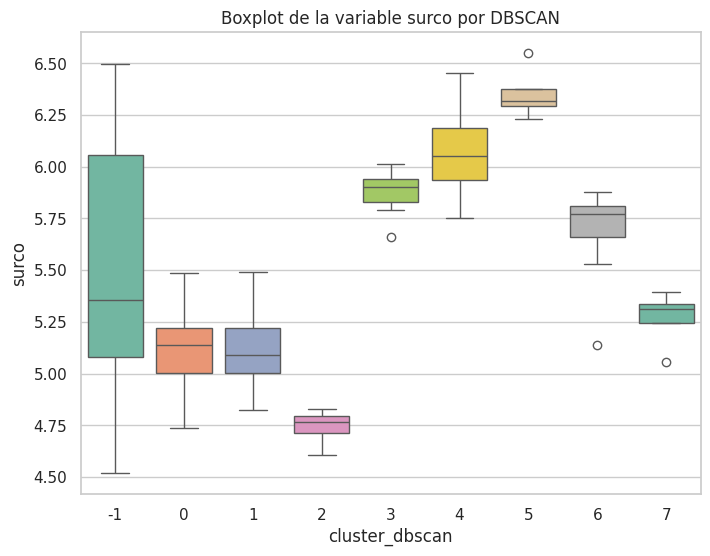

<ipython-input-58-65e60c459118>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_kmeans', y='surco', data=df, palette="Set2")


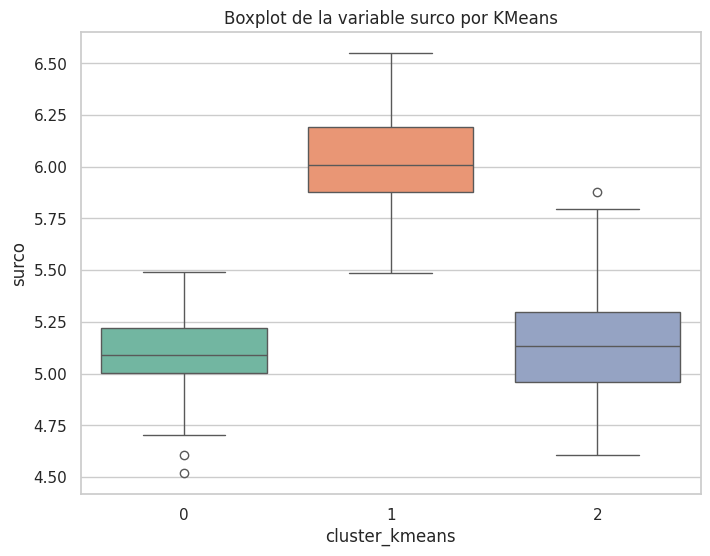

<ipython-input-58-65e60c459118>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_agg', y='surco', data=df, palette="Set2")


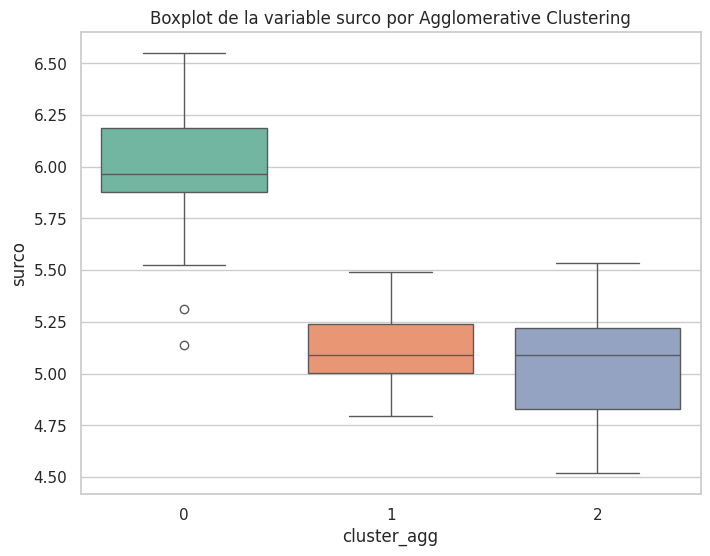

In [ ]:
import seaborn as sns

# Añadimos la variable surco al DataFrame
df['cluster_dbscan'] = dbscan_etiq
df['cluster_kmeans'] = etiq_kmeans
df['cluster_agg'] = etiq_agg

# Boxplot para DBSCAN
plt.figure(figsize=(8, 6))
sns.boxplot(x='cluster_dbscan', y='surco', data=df, palette="Set2")
plt.title('Boxplot de la variable surco por DBSCAN')
plt.show()

# Boxplot para KMeans
plt.figure(figsize=(8, 6))
sns.boxplot(x='cluster_kmeans', y='surco', data=df, palette="Set2")
plt.title('Boxplot de la variable surco por KMeans')
plt.show()

# Boxplot para AgglomerativeClustering
plt.figure(figsize=(8, 6))
sns.boxplot(x='cluster_agg', y='surco', data=df, palette="Set2")
plt.title('Boxplot de la variable surco por Agglomerative Clustering')
plt.show()


### Análisis de los clusters mediante Boxplots de la variable "surco"

Los **boxplots** de la variable **"surco"** nos permiten analizar la distribución de esta variable dentro de los clusters generados por cada uno de los algoritmos de clustering. A continuación, se presentan los **boxplots** para **DBSCAN**, **KMeans** y **Agglomerative Clustering**.

1. **DBSCAN**:
   - Se observa una **gran dispersión en los valores** de la variable "surco" para el cluster `-1` (ruido), lo que indica que los puntos ruidosos no siguen una distribución clara.
   - Los clusters **0, 1, 2, 3, 4, 5, 6, 7** tienen **distribuciones** de la variable "surco" relativamente bien diferenciadas, con **valores de mediana distintos**.
   - El **cluster 0** parece tener valores de "surco" más altos, mientras que el **cluster 1** tiene valores más bajos.

2. **KMeans**:
   - Los **clusters 0, 1, 2** muestran **distribuciones separadas** de "surco".
   - El **cluster 0** tiene valores de "surco" más altos, mientras que **el cluster 1** tiene la mediana más baja.
   - El **cluster 2** también muestra una distribución de valores algo más baja.

3. **Agglomerative Clustering**:
   - Similar a **KMeans**, los clusters 0, 1, y 2 en **Agglomerative Clustering** también obtienen **distribuciones separadas** de "surco".
   - El **cluster 0** tiene la mediana más alta de "surco", mientras que el **cluster 2** muestra valores más bajos de esta variable.

### Conclusiones del análisis de Boxplots:

- **DBSCAN** muestra una distribución más amplia para los puntos ruidosos (`-1`), y los clusters detectados tienen una mayor dispersión en los valores de "surco".
- **KMeans** y **Agglomerative Clustering** muestran una **distribución más homogénea** dentro de los clusters, puede ser útil para casos donde se buscan **grupos más equilibrados**.

En resumen, todos los métodos generan **clusters bien definidos**, pero DBSCAN tiene la ventaja de identificar **puntos ruidosos** y **clusters con variabilidad interna más grande**, mientras que KMeans y Agglomerative Clustering proporcionan **clusters más homogéneos** en cuanto a la variable "surco".


# **5. Uso de ChatGPT**

Durante el desarrollo de esta práctica, hemos utilizado **ChatGPT** como una herramienta para **resolver dudas conceptuales** relacionadas con el temario y para **la elaboración de gráficos**.

1. **Resolución de dudas conceptuales**:
   - A lo largo de la práctica, surgieron dudas sobre los conceptos clave en **clustering** y el uso de **algoritmos como DBSCAN, KMeans y Agglomerative Clustering**.
   - ChatGPT nos proporcionó **explicaciones claras** y **ejemplos prácticos** sobre estos algoritmos, ayudándonos a comprender mejor su funcionamiento, su implementación y las métricas de evaluación utilizadas en el análisis de clustering.
   
2. **Elaboración de gráficos**:
   - Para visualizar los resultados de los algoritmos de clustering, hemos utilizado gráficos como **scatter plots** y **boxplots**.
   - ChatGPT nos proporcionó **código para generar estos gráficos** de manera eficiente, facilitando la visualización de los clusters y ayudándonos a interpretar los resultados de manera más efectiva.



# **6. Conclusión**

En esta práctica hemos comparado tres métodos de clustering: **DBSCAN**, **KMeans** y **Agglomerative Clustering**.

- **DBSCAN** mostró un **ARI de 0.406**, identificando correctamente regiones densas y detectando ruido, pero con **menor alineación con las clases reales**. Su mayor dispersión de los clusters y la detección de ruido fueron las características más destacadas.

- **KMeans** (con `k=3`) y **Agglomerative Clustering** presentaron **ARIs de 0.750 y 0.754**, respectivamente, indicando **una alta coincidencia con las clases reales**. Ambos métodos generaron clusters compactos y bien definidos, con **KMeans** siendo el más robusto en términos de segmentación.

**En resumen**, **KMeans** y **Agglomerative Clustering** fueron los métodos más adecuados para este problema, proporcionando **mejores resultados** en comparación con **DBSCAN**, especialmente en términos de **coincidencia con las clases reales**.
